In [1]:
import subprocess
import re
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import seaborn as sns

In [2]:
# 可执行程序路径
EXECUTABLE = "../anchor_mapping"

plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial'] 
plt.rcParams['axes.unicode_minus'] = False 

# --- 脚本配置 ---
# 可执行程序路径
EXECUTABLE = "../anchor_mapping"

# 定义所有需要提取的指标 (Accesses 和 PR 指标都在这里)
ALL_PATTERNS = {
    # 最终 Accesses 统计
    "index_accesses":     r"Index accesses:\s*([0-9]+)", # 注意：这里如果 C++ 输出格式是 "Index Accesses: 0"
    "candidate_accesses": r"Candidate accesses:\s*([0-9]+)", # 请确保 Accesses 提取模式与 C++ 输出完全匹配

    # 平均 PR 指标
    "avg_tp":             r"Average TP:\s*([0-9.eE+-]+)",
    "avg_fp":             r"Average FP:\s*([0-9.eE+-]+)",
    "avg_fn":             r"Average FN:\s*([0-9.eE+-]+)",
    "avg_recall":         r"Average Recall:\s*([0-9.eE+-]+)",
    "avg_precision":      r"Average Precision:\s*([0-9.eE+-]+)",
}

In [3]:
def plot_accesses_stacked_bar(df, sweep_param_name, title_suffix, fig_path):
    """
    通用函数：绘制 Index/Candidate Accesses 堆叠柱状图。
    """
    if 'index_accesses' in df.columns and 'candidate_accesses' in df.columns:
        plt.figure(figsize=(10, 6))

        # 绘制 Index Accesses 柱状图 (底部)
        plt.bar(
            df[sweep_param_name],
            df["index_accesses"],
            width=df[sweep_param_name].diff().min() * 0.8 if len(df) > 1 else 1.5, # 动态调整柱子宽度
            label='Index Accesses',
            color='tab:blue'
        )

        # 绘制 Candidate Accesses 柱状图 (堆叠在 Index Accesses 之上)
        plt.bar(
            df[sweep_param_name],
            df["candidate_accesses"],
            width=df[sweep_param_name].diff().min() * 0.8 if len(df) > 1 else 1.5,
            bottom=df["index_accesses"], # 关键：使用 index_accesses 作为底部
            label='Candidate Accesses',
            color='tab:orange'
        )

        plt.xlabel(f"{sweep_param_name.replace('_', ' ').title()}")
        plt.ylabel("Total Accesses Count (Index + Candidate)")
        plt.title(f"Index and Candidate Accesses Sweep on {sweep_param_name.replace('_', ' ').title()} ({title_suffix})")
        plt.legend()
        plt.grid(axis='y', linestyle=':', alpha=0.7)

        # 设置 X 轴刻度，确保每个值都显示
        plt.xticks(df[sweep_param_name])
        plt.show()
        plt.savefig(fig_path)
        print(f"Accesses 堆叠柱状图已保存至: {fig_path}")
        # plt.show()
    else:
        print(f"\n⚠️ 缺失 Accesses 数据，无法生成 {title_suffix} 的堆叠柱状图。请检查程序输出。")
    plt.close() # 关闭图形，释放内存

In [4]:
def run_batch_experiment(method_name, maxDist_list, fixed_seed_len="16"):
    """
    新函数：执行 C++ 程序一次，传入 maxDist 列表，并解析所有批次结果。
    """
    print(f"\n# ==========================================================================")
    print(f"=== BATCH SWEEP maxDist (Method: {method_name.upper()}) ===")
    print(f"=========================================================================#")
    
    # 将 maxDist 列表转换为 C++ 期望的逗号分隔字符串
    maxDist_str = ",".join(map(str, maxDist_list))
    print(maxDist_str)
    sweep_param = "maxDist"
    
    # 1. 构建命令行参数 (只需执行一次)
    cmd = [
        EXECUTABLE,
        "--truncate_ref_len", "100000", # full length
        "--anchor_len", "30",
        "--num_anchors", "10000",
        "--seed_len", fixed_seed_len,
        "--num_queries", "10000",
        # 关键修改：传入 maxDist 列表
        "--maxDist", maxDist_str,  
        "--auto_gen", "false",
        "--method", method_name,
        "--require_distance"
    ]
    
    print(f"Executing: {' '.join(cmd)}")
    
    try:
        # 执行 C++ 程序，它会在内部循环并打印分隔符
        proc = subprocess.run(cmd, capture_output=True, text=True, check=True)
    except subprocess.CalledProcessError as e:
        print(f"Error running batch command: Return code {e.returncode}. Stderr: {e.stderr}")
        return None
    except FileNotFoundError:
        print(f"Error: Executable not found at {EXECUTABLE}. Please check the path.")
        sys.exit(1)

    full_output = proc.stdout
    all_results = []
    
    # 2. 根据分隔符切分输出
    # 切分字符串，[1:] 是为了跳过索引构建和初始日志部分
    run_chunks = re.split(r"--- START_BATCH_RUN ---\n", full_output)[1:]

    if not run_chunks:
        print("⚠️ 警告: 未找到任何 START_BATCH_RUN 标记，请检查 C++ 输出。")
        return pd.DataFrame()
        
    # 3. 循环解析每个运行块
    for chunk in run_chunks:
        metrics = {'method': method_name}
        
        # 3.1 提取当前运行的参数 (maxDist)
        # 提取当前运行的 maxDist 参数，假设格式为 'query_maxDist: 3'
        max_dist_match = re.search(r"query_maxDist: (\d+)", chunk)
        
        if not max_dist_match:
            print("⚠️ 警告: 无法解析当前运行的 maxDist 参数，跳过该块。")
            continue

        current_max_dist = int(max_dist_match.group(1))
        metrics[sweep_param] = current_max_dist
        
        # 3.2 在当前块中提取所有指标
        for key, pat in ALL_PATTERNS.items():
            # 注意：在 chunk 中查找
            m = re.search(pat, chunk)
            
            if m:
                # 您的原始解析逻辑
                print(key, m.group(1))
                metrics[key] = int(m.group(1)) if 'accesses' in key else float(m.group(1))
            else:
                # 找不到指标时
                metrics[key] = 0 if 'accesses' in key else None

        # 3.3 (NEW) 提取 SAE 距离列表
        # 使用 re.DOTALL (或 re.S) 允许 '.' 匹配换行符
        dist_pattern = r"DISTANCES_START:(.*?)\nDISTANCES_END"
        dist_match = re.search(dist_pattern, chunk, re.DOTALL)
        
        if dist_match:
            distances_str = dist_match.group(1).strip()
            if distances_str:
                try:
                    # 将所有以空格分隔的数字转换为浮点数列表
                    distance_list = [float(x) for x in distances_str.split()]
                    metrics['distances'] = distance_list
                except ValueError as e:
                    print(f"⚠️ 警告: 解析 SAE 距离时出错: {e}. 字符串: '{distances_str[:50]}...'")
                    metrics['distances'] = [] # 出错时存入空列表
            else:
                metrics['distances'] = [] # 找到了标记，但是中间是空的
        else:
            # 如果未找到该块 (例如 method != 'sae' 或 require_distance=False)
            metrics['distances'] = [] # 存入空列表
            
        all_results.append(metrics)
        
    # 4. 数据处理和可视化
    df = pd.DataFrame(all_results)
    
    # ... (保持 run_method_sweep 尾部的保存和绘图逻辑)
    
    if df.empty:
        print(f"{method_name.upper()} 实验结果为空，跳过保存和绘图。")
        return

    print(f"\n--- {method_name.upper()} 结果 DataFrame ---")
    print(df)

    # 定义输出路径
    csv_path = f"./csv/sweep_results_maxDist_{method_name}.csv"
    fig_pr_path = f"./fig/sweep_precision_recall_maxDist_{method_name}.png"
    fig_access_path = f"./fig/sweep_accesses_maxDist_{method_name}.png"
    fig_violin_path = f"./fig/sweep_distances_violin_maxDist_{method_name}.png"

    os.makedirs(os.path.dirname(csv_path), exist_ok=True)
    os.makedirs(os.path.dirname(fig_pr_path), exist_ok=True)

    # 1. 保存结果
    df.to_csv(csv_path, index=False)
    print(f"\n{method_name.upper()} 结果已保存至: {csv_path}")

    # 2. 绘图 1: Precision 和 Recall
    plt.figure(figsize=(10, 6))
    plt.plot(df[sweep_param], df["avg_precision"], marker="o", label='Precision')
    plt.plot(df[sweep_param], df["avg_recall"], marker="s", label='Recall')
    plt.xlabel("Max Distance (Error Tolerance)")
    plt.ylabel("Average Metric Value")
    plt.title(f"Effect of Max Distance on Precision and Recall (Method: {method_name.upper()})")
    plt.legend()
    plt.grid(True)
    # plt.show() # 如果是自动运行脚本，通常不 show
    plt.savefig(fig_pr_path)
    print(f"{method_name.upper()} Precision/Recall 图已保存至: {fig_pr_path}")
    plt.close()

    # 3. 绘图 2: Index/Candidate Accesses 堆叠柱状图
    plot_accesses_stacked_bar(df, sweep_param, f"Method: {method_name.upper()}", fig_access_path)

    # 4. 绘图 3: 距离小提琴图
    if 'distances' in df.columns:
        # 检查是否有任何数据（列表长度总和是否大于0）
        if df['distances'].apply(len).sum() > 0:
            
            # A. 数据转换：将包含列表的列 'distances' 展开 (explode) 为长格式
            #    原始: (maxDist=1, distances=[1.1, 1.2])
            #    展开后: (maxDist=1, distance_value=1.1), (maxDist=1, distance_value=1.2)
            
            # 选择我们需要的列
            df_dist_long = df[[sweep_param, 'distances']].copy()
            # 展开列表
            df_dist_long = df_dist_long.explode('distances')
            
            # B. 清理和类型转换
            # 重命名列以便绘图
            df_dist_long = df_dist_long.rename(columns={'distances': 'distance_value'})
            # 将 maxDist 转换为类别 (category)，这有助于 seaborn 正确排序和分组
            df_dist_long[sweep_param] = df_dist_long[sweep_param].astype('category')
            # 确保距离值是数字
            df_dist_long['distance_value'] = pd.to_numeric(df_dist_long['distance_value'])

            # C. 绘图
            plt.figure(figsize=(12, 7))
            sns.violinplot(
                data=df_dist_long,
                x=sweep_param,            # X 轴：maxDist
                y='distance_value', # Y 轴：单个距离值
                inner='quartile',       # 'quartile' 在小提琴内部显示中位数和四分位数
                scale='width'           # 'width' 确保所有小提琴有相同的宽度
            )
            
            plt.xlabel("Max Distance (Error Tolerance)")
            plt.ylabel("Candidate Average Distance (per query)")
            plt.title(f"Distribution of Candidate Distances (Method: {method_name.upper()})")
            plt.grid(axis='y', linestyle=':', alpha=0.7)
            
            plt.savefig(fig_violin_path)
            print(f"{method_name.upper()} 距离小提琴图已保存至: {fig_violin_path}")
            plt.close()
        else:
            print(f"\n⚠️ {method_name.upper()} 缺失 'distances' 数据 (列表为空)，跳过小提琴图。")
    else:
        print(f"\n⚠️ {method_name.upper()} 未找到 'distances' 列，跳过小提琴图。")

    return df # 返回 DataFrame 供总对比使用

In [5]:
def plot_comparison_figures(all_df, sweep_param_name):
    """
    绘制对比 Precision/Recall 和 Index/Candidate 堆叠 Accesses 的总图。
    """
    print("\n# ==========================================================================")
    print("=== FINAL PART: Plotting Comparison Figures ===")
    print("=========================================================================#")

    if all_df.empty:
        print("所有实验结果为空，无法生成总对比图。")
        return

    # --- 图 1: Precision 和 Recall 对比图 (保持不变) ---
    plt.figure(figsize=(12, 8))
    
    # 获取唯一的 maxDist 值用于设置 x 轴刻度
    x_ticks = all_df[sweep_param_name].unique()
    methods = all_df['method'].unique()
    num_methods = len(methods)
    
    styles = {
        'sae':    {'marker': 'o', 'color': 'tab:blue'},
        'anchor': {'marker': 's', 'color': 'tab:green'},
        'mtree':  {'marker': '^', 'color': 'tab:red'}
    }

    # 1. 绘制 Precision
    ax1 = plt.gca()
    for method in methods:
        df_method = all_df[all_df['method'] == method]
        style = styles.get(method, {})
        ax1.plot(df_method[sweep_param_name], df_method["avg_precision"], 
                 label=f'{method.upper()} Precision', 
                 linestyle='-', **style)

    # 2. 绘制 Recall
    for method in methods:
        df_method = all_df[all_df['method'] == method]
        style = styles.get(method, {})
        ax1.plot(df_method[sweep_param_name], df_method["avg_recall"], 
                 label=f'{method.upper()} Recall', 
                 linestyle='--', **style)

    ax1.set_xlabel("Max Distance (Error Tolerance)")
    ax1.set_ylabel("Average Metric Value (Precision/Recall)")
    ax1.set_title("Comparison of Precision and Recall Across Methods")
    ax1.legend(loc='lower right')
    ax1.grid(True)
    ax1.set_xticks(x_ticks) # 设置 X 轴刻度
    
    fig_pr_comp_path = "./fig/comparison_precision_recall_maxDist.png"
    plt.show()
    plt.savefig(fig_pr_comp_path)
    print(f"总 Precision/Recall 对比图已保存至: {fig_pr_comp_path}")
    plt.close()

    # --- 图 2: Index/Candidate 堆叠 Accesses 分组柱状图 (修改部分) ---
    if 'index_accesses' in all_df.columns and 'candidate_accesses' in all_df.columns:
        plt.figure(figsize=(12, 6))
        ax2 = plt.gca()
        
        max_dists = all_df[sweep_param_name].unique()
        
        # 动态计算柱子宽度
        bar_width = 0.8 / num_methods # 0.8 是组内总宽度
        
        # 定义颜色的映射
        method_colors = {
            'sae': 'tab:blue',
            'anchor': 'tab:green',
            'mtree': 'tab:red'
        }
        
        # 遍历每个 maxDist 作为一组
        for i, max_d in enumerate(max_dists):
            df_group = all_df[all_df[sweep_param_name] == max_d].copy()
            
            # 确保方法按固定顺序排列，以便柱子顺序一致
            df_group['method'] = pd.Categorical(df_group['method'], categories=methods, ordered=True)
            df_group = df_group.sort_values('method')
            
            # 计算组内起始位置 (用于左移/右移)
            center_x = i
            group_start_x = center_x - (bar_width * num_methods / 2) + (bar_width / 2)
            
            # 遍历组内的每个方法绘制堆叠柱子
            for j, method in enumerate(df_group['method']):
                data = df_group[df_group['method'] == method].iloc[0]
                
                index_count = data['index_accesses']
                candidate_count = data['candidate_accesses']
                print("index access:", index_count)
                
                bar_pos = group_start_x + j * bar_width
                
                # 绘制 Index Accesses (底部)
                ax2.bar(bar_pos, index_count, bar_width, 
                        color=method_colors[method], alpha=0.9, 
                        label=f'{method.upper()} Index' if i == 0 else "", # 只在第一个 maxDist 组添加标签
                        edgecolor='black')
                
                # 绘制 Candidate Accesses (堆叠在 Index 之上)
                ax2.bar(bar_pos, candidate_count, bar_width, 
                        bottom=index_count, 
                        color=method_colors[method], alpha=0.5, 
                        label=f'{method.upper()} Candidate' if i == 0 else "", 
                        edgecolor='black')

        # 设置 X 轴刻度：显示 maxDist 值，并将其放置在分组的中心
        ax2.set_xticks(range(len(max_dists)))
        ax2.set_xticklabels(max_dists)
        
        # 设置 Y 轴为对数刻度 (Log Scale)
        ax2.set_yscale('log')
        
        ax2.set_xlabel("Max Distance (Error Tolerance)")
        ax2.set_ylabel("Accesses Count (Index + Candidate, Log Scale)")
        ax2.set_title("Comparison of Index/Candidate Stacked Accesses Across Methods (Log Scale)")
        
        # 创建自定义图例：使用两个循环，一个用于 Index（深色），一个用于 Candidate（浅色）
        legend_handles = []
        for method in methods:
            color = method_colors[method]
            # Index (深色)
            legend_handles.append(plt.Rectangle((0, 0), 1, 1, fc=color, alpha=0.9, label=f'{method.upper()} Index'))
            # Candidate (浅色)
            legend_handles.append(plt.Rectangle((0, 0), 1, 1, fc=color, alpha=0.5, label=f'{method.upper()} Candidate'))

        ax2.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.01, 1))
        ax2.grid(axis='y', linestyle=':', alpha=0.7)
        
        plt.tight_layout(rect=[0, 0, 0.95, 1]) # 调整布局以适应图例
        
        fig_access_comp_path = "./fig/comparison_accesses_grouped_stacked_log_maxDist.png"
        plt.show()
        plt.savefig(fig_access_comp_path)
        print(f"总 Accesses 堆叠分组柱状图（Log Y）已保存至: {fig_access_comp_path}")
        plt.close()
    else:
        print("⚠️ 无法计算 Accesses，跳过 Accesses 对比图。")

    # --- 图 3: SAE 距离分布对比小提琴图 ---
    if 'distances' in all_df.columns:
        # 筛选出那些 'distances' 列表不为空的行，并使用 .copy() 明确操作一个副本
        df_with_dist = all_df[all_df['distances'].apply(lambda x: x is not None and len(str(x).strip()) > 0)].copy()

        if not df_with_dist.empty:
            
            # 0. 【修正】转换：将字符串形式的列表安全地转换为 Python 列表对象
            try:
                # 明确使用 .loc 进行赋值，避免 SettingWithCopyWarning
                # 假设 df_with_dist['distances'] 中的数据是字符串
                df_with_dist.loc[:, 'distances'] = df_with_dist['distances'].apply(literal_eval)
            except (ValueError, TypeError) as e:
                print(f"⚠️ 无法使用 literal_eval 转换 'distances' 列: {e}")
                # 如果转换失败，可以直接返回或跳过
                # return
                pass 

            # A. 数据转换：展开 (Explode)
            df_long = df_with_dist.explode('distances')

            # B. 清理和类型转换
            df_long = df_long.rename(columns={
                'distances': 'distance_value',
                sweep_param_name: 'Max Distance'
            })
            
            # 将展开后的 'distance_value' 转换为数值类型
            df_long['distance_value'] = pd.to_numeric(df_long['distance_value'], errors='coerce')
            # 删除转换失败的（NaN）行
            df_long.dropna(subset=['distance_value'], inplace=True)
            df_long['Max Distance'] = df_long['Max Distance'].astype('category')
            
            # 重点：确保 'method' 也是分类类型，有助于绘图顺序
            df_long['method'] = df_long['method'].astype('category')

            # C. 绘图 (使用 figure 和 ax 或 FacetGrid)
            
            # 使用 catplot 实现分组小提琴图：
            # - x: Max Distance (组)
            # - hue: method (组内分组)
            # - dodge=True: 让不同 method 的小提琴图并排显示
            g = sns.catplot(
                data=df_long,
                x='Max Distance',
                y='distance_value',
                hue='method',            # <--- 关键：用颜色区分方法
                kind='violin',
                inner='quartile',
                sharey=True,
                dodge=True,              # <--- 关键：使小提琴图并排显示
                height=6,
                aspect=2,
            )
            
            # 设置总标题和轴标签
            g.fig.suptitle("Comparison of Candidate Distance Distributions Across Methods", y=1.03)
            g.set_axis_labels(sweep_param_name.replace('_', ' ').title(), "Candidate Distance Value")
            
            # 调整图例标题
            g._legend.set_title("Method")
            # plt.tight_layout(rect=[0, 0, 1, 1]) # 确保标题在图上
            plt.show()
        
        else:
            print("⚠️ 'distances' 列中没有有效数据。")
    else:
        print("⚠️ 无法找到 'distances' 列，跳过小提琴图。")
        
    return


# ==========================================================================
=== BATCH SWEEP maxDist (Method: SAE) ===
=========================================================================#
1,4,7
Executing: ../anchor_mapping --truncate_ref_len 100000 --anchor_len 30 --num_anchors 10000 --seed_len 16 --num_queries 10000 --maxDist 1,4,7 --auto_gen false --method sae --require_distance
index_accesses 107
candidate_accesses 107
avg_tp 1
avg_fp 0
avg_fn 0
avg_recall 1
avg_precision 1
index_accesses 456
candidate_accesses 4586
avg_tp 2.85965
avg_fp 37.1228
avg_fn 0.0350877
avg_recall 0.987879
avg_precision 0.0715226
index_accesses 840
candidate_accesses 383920
avg_tp 2.96667
avg_fp 3069.35
avg_fn 0.0583333
avg_recall 0.980716
avg_precision 0.000965612

--- SAE 结果 DataFrame ---
  method  maxDist  index_accesses  candidate_accesses   avg_tp     avg_fp  \
0    sae        1             107                 107  1.00000     0.0000   
1    sae        4             456                4586  2.85

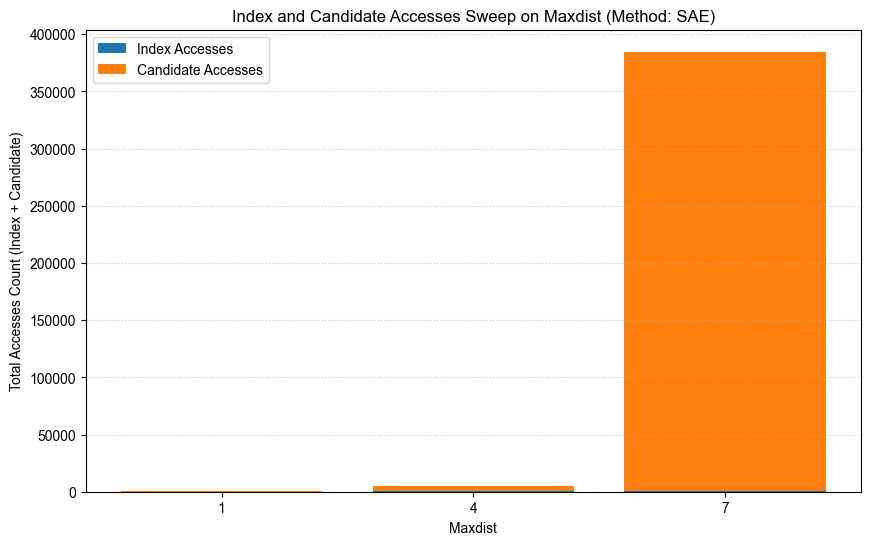

Accesses 堆叠柱状图已保存至: ./fig/sweep_accesses_maxDist_sae.png
SAE 距离小提琴图已保存至: ./fig/sweep_distances_violin_maxDist_sae.png

# ==========================================================================
=== BATCH SWEEP maxDist (Method: MTREE) ===
=========================================================================#
1,4,7
Executing: ../anchor_mapping --truncate_ref_len 100000 --anchor_len 30 --num_anchors 10000 --seed_len 16 --num_queries 10000 --maxDist 1,4,7 --auto_gen false --method mtree --require_distance


/tmp/ipykernel_56840/3412762121.py:169: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


index_accesses 908381
candidate_accesses 107
avg_tp 1
avg_fp 0
avg_fn 0
avg_recall 1
avg_precision 1
index_accesses 977129
candidate_accesses 568
avg_tp 2.89474
avg_fp 0.0701754
avg_fn 0
avg_recall 1
avg_precision 0.976331
index_accesses 1036065
candidate_accesses 916
avg_tp 2.99167
avg_fp 0.391667
avg_fn 0.0333333
avg_recall 0.988981
avg_precision 0.884236

--- MTREE 结果 DataFrame ---
  method  maxDist  index_accesses  candidate_accesses   avg_tp    avg_fp  \
0  mtree        1          908381                 107  1.00000  0.000000   
1  mtree        4          977129                 568  2.89474  0.070175   
2  mtree        7         1036065                 916  2.99167  0.391667   

     avg_fn  avg_recall  avg_precision  \
0  0.000000    1.000000       1.000000   
1  0.000000    1.000000       0.976331   
2  0.033333    0.988981       0.884236   

                                           distances  
0  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  
1  [2.4, 2.4, 2.4, 2.4, 2.4,

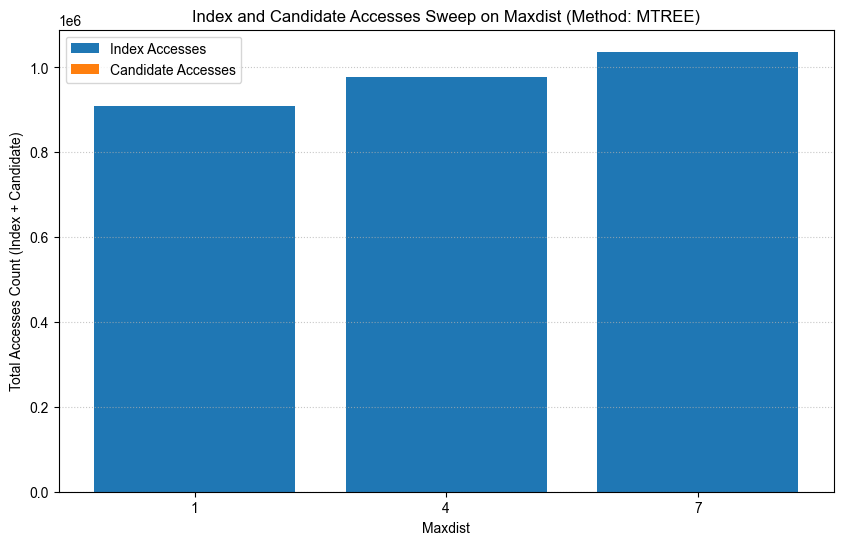

Accesses 堆叠柱状图已保存至: ./fig/sweep_accesses_maxDist_mtree.png
MTREE 距离小提琴图已保存至: ./fig/sweep_distances_violin_maxDist_mtree.png


/tmp/ipykernel_56840/3412762121.py:169: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


In [6]:
# 1. 定义遍历参数
MAX_DIST_VALUES = range(1, 8, 3) # maxDist 从 1 到 28

# 2. 定义要测试的方法
METHODS_TO_TEST = ["sae", "mtree"]

# 3. 循环运行所有方法 (现在这个循环只执行方法级的批处理)
all_results_df = []
for method in METHODS_TO_TEST:
    # 调用批处理函数
    df_result = run_batch_experiment(method, MAX_DIST_VALUES) 
    if df_result is not None and not df_result.empty:
        all_results_df.append(df_result)

In [7]:
# final_comparison_df_1 = final_comparison_df.iloc[range(0, len(final_comparison_df), 2), :]


# ==========================================================================
=== FINAL PART: Plotting Comparison Figures ===
=========================================================================#


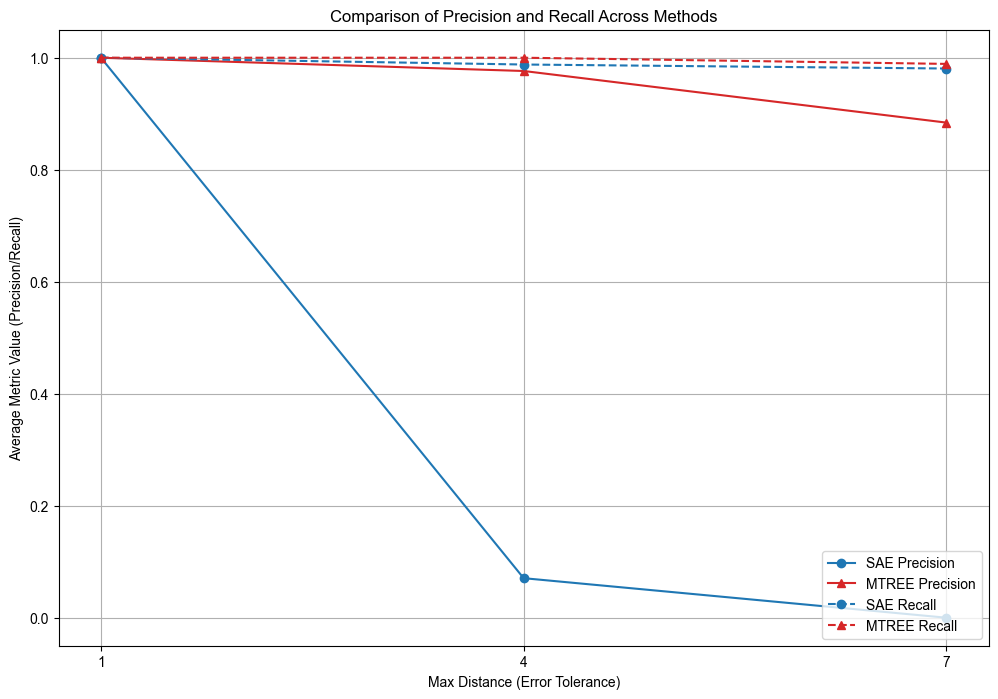

总 Precision/Recall 对比图已保存至: ./fig/comparison_precision_recall_maxDist.png
index access: 107
index access: 908381
index access: 456
index access: 977129
index access: 840
index access: 1036065


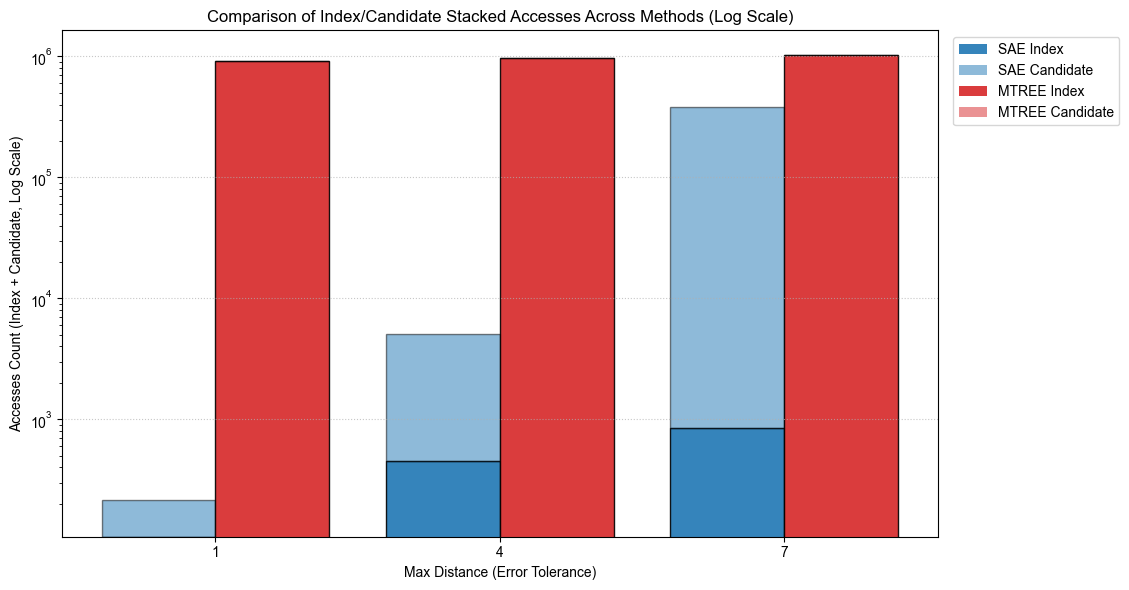

总 Accesses 堆叠分组柱状图（Log Y）已保存至: ./fig/comparison_accesses_grouped_stacked_log_maxDist.png
⚠️ 无法使用 literal_eval 转换 'distances' 列: malformed node or string: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


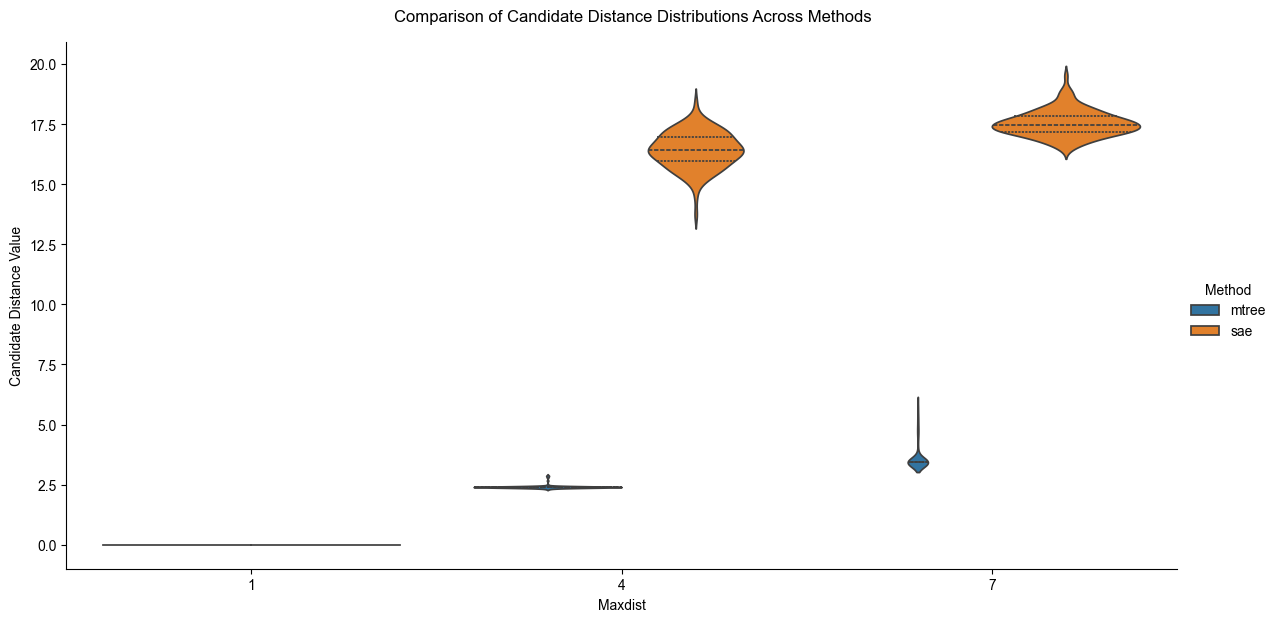

In [8]:
from ast import literal_eval
if all_results_df:
    final_comparison_df = pd.concat(all_results_df, ignore_index=True)
    plot_comparison_figures(final_comparison_df, "maxDist")
else:
    print("\n所有实验均未返回有效数据，无法生成总对比图。")

In [9]:
# final_comparison_df.to_csv("./csv/comparison_distance1_30_sae_mt.csv")